# Final Project: Teaching Step by Step

This notebook is a guided solution framework for the final long-read microbiome project.

It follows the same style as the previous homework notebooks: each section states what the assignment asks, shows the commands or Python used to answer it, and then gives the answer/conclusion.

Important note: this notebook can reproduce the host-origin, host functional-region, microbiome classification, and microbial assembly analysis when the Group D FASTQ bundle, command-line tools, public references, and optional NCBI API key file are available locally. Heavy files are skipped when already present.


## 0. Setup

Expected layout:

```text
FinalProject/
  .secret.ncbi                  # optional, gitignored NCBI API key
  report_FBG58625_GroupD.html
  NanoComp-report.html
  group_d_unmapped.fastq.gz
  group_d.q10_l500.first300k.fastq.gz
  group_d.host_unmapped.fastq.gz
  kraken2_db/                   # downloaded/extracted if missing
  flye_proteus_mirabilis/       # assembled if missing
  data/ and results/            # older nested layout is also supported
```

The notebook avoids printing secrets. Missing data is reported clearly so the same notebook can be used both as a write-up and as a runnable analysis plan.


## Colab Dependency Install

Run this cell once near the start of a fresh Colab runtime. It installs command-line tools used by the reproducible workflow.


In [1]:
import os
import shutil

IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in str(get_ipython())
print('Running in Colab:', IN_COLAB)


Running in Colab: False


In [2]:
# In Colab this installs the command-line tools used below.
# Outside Colab, the shell condition keeps this cell harmless for local smoke tests.
!if [ -n "$COLAB_RELEASE_TAG" ]; then apt-get update -qq; else echo "Not Colab; skipping apt-get update"; fi
!if [ -n "$COLAB_RELEASE_TAG" ]; then apt-get install -y -qq samtools minimap2 kraken2 mummer; else echo "Not Colab; skipping apt-get install"; fi
!if [ -n "$COLAB_RELEASE_TAG" ]; then python -m pip install -q pandas matplotlib lxml html5lib flye; else echo "Not Colab; skipping pip install"; fi


Not Colab; skipping apt-get update


Not Colab; skipping apt-get install


Not Colab; skipping pip install


In [3]:
import shutil
print('samtools:', shutil.which('samtools'))
print('minimap2:', shutil.which('minimap2'))


samtools: None
minimap2: None


In [4]:
from pathlib import Path
import bisect
import gzip
import html
import json
import os
import re
import shlex
import shutil
import subprocess
import tarfile
import urllib.request

import pandas as pd
from IPython.display import display, Markdown, Image


def detect_project_dir():
    env_root = os.environ.get('FINALPROJECT_ROOT')
    if env_root:
        return Path(env_root).expanduser().resolve()
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / 'FinalProject',
        Path('/content/drive/MyDrive/FinalProject'),
        Path('/content/drive/MyDrive/CompGenomicsWS/FinalProject'),
        Path('/content/FinalProject'),
    ]
    for candidate in candidates:
        if (candidate / 'FinalProject_Teaching_Step_By_Step.ipynb').exists() or (candidate / 'README.md').exists() or (candidate / 'report_FBG58625_GroupD.html').exists():
            return candidate
    return cwd

PROJECT_DIR = detect_project_dir()
FLAT_DIR = PROJECT_DIR
NESTED_DATA_DIR = PROJECT_DIR / 'data'
NESTED_RESULTS_DIR = PROJECT_DIR / 'results'
NESTED_REFERENCE_DIR = NESTED_DATA_DIR / 'references'
NESTED_TOOLS_DIR = PROJECT_DIR / 'tools'

# Prefer the flat notebook folder for portable/Drive bundles; fall back to the original repo layout.
DATA_DIR = FLAT_DIR
RESULTS_DIR = FLAT_DIR
REFERENCE_DIR = FLAT_DIR
TOOLS_DIR = FLAT_DIR
RESULTS_DIR.mkdir(exist_ok=True)


def find_file(name, search_dirs=None):
    search_dirs = search_dirs or [FLAT_DIR, DATA_DIR, REFERENCE_DIR, RESULTS_DIR, NESTED_DATA_DIR, NESTED_REFERENCE_DIR, NESTED_RESULTS_DIR]
    for directory in search_dirs:
        candidate = Path(directory) / name
        if candidate.exists() and candidate.stat().st_size > 0:
            return candidate
    return None


def find_executable(name, candidates=None):
    candidates = candidates or []
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists() and os.access(candidate, os.X_OK):
            return candidate
    system_path = shutil.which(name)
    return Path(system_path) if system_path else None

MINKNOW_REPORT = find_file('report_FBG58625_GroupD.html', [FLAT_DIR, PROJECT_DIR, NESTED_DATA_DIR]) or (FLAT_DIR / 'report_FBG58625_GroupD.html')
NANOCOMP_REPORT = find_file('NanoComp-report.html', [FLAT_DIR, PROJECT_DIR, NESTED_DATA_DIR]) or (FLAT_DIR / 'NanoComp-report.html')
NCBI_SECRET_FILE = find_file('.secret.ncbi', [FLAT_DIR, PROJECT_DIR])

MINIMAP2 = find_executable('minimap2', [FLAT_DIR / 'minimap2', NESTED_TOOLS_DIR / 'minimap2-2.28_x64-linux' / 'minimap2'])
SAMTOOLS = find_executable('samtools', [Path('/home/orgr/anaconda3/envs/bioinfo/bin/samtools')])

NCBI_API_KEY = None
if NCBI_SECRET_FILE:
    NCBI_API_KEY = NCBI_SECRET_FILE.read_text().strip()
elif os.environ.get('NCBI_API_KEY'):
    NCBI_API_KEY = os.environ['NCBI_API_KEY'].strip()

NCBI_HEADERS = {}
if NCBI_API_KEY:
    NCBI_HEADERS['api-key'] = NCBI_API_KEY


def urlretrieve_if_needed(url, output_path, description, headers=None):
    output_path = Path(output_path)
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f'Skipping {description}; output already exists.')
        return
    print(f'Downloading {description}...')
    request = urllib.request.Request(url, headers=headers or {})
    with urllib.request.urlopen(request) as response, output_path.open('wb') as handle:
        shutil.copyfileobj(response, handle)


def run_if_needed(outputs, command, description, shell=False):
    outputs = [Path(o) for o in outputs]
    if outputs and all(o.exists() and o.stat().st_size > 0 for o in outputs):
        print(f'Skipping {description}; output already exists.')
        return
    print(f'Running {description}:')
    if shell:
        print(command)
        subprocess.run(command, shell=True, check=True)
    else:
        print(' '.join(shlex.quote(str(x)) for x in command))
        subprocess.run([str(x) for x in command], check=True)

print('Project directory:', PROJECT_DIR)
print('MinKNOW report exists:', MINKNOW_REPORT.exists())
print('NanoComp report exists:', NANOCOMP_REPORT.exists())
print('NCBI API key loaded:', bool(NCBI_API_KEY))
print('minimap2 path:', MINIMAP2 if MINIMAP2 else 'missing')
print('samtools path:', SAMTOOLS if SAMTOOLS else 'missing')


Project directory: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject
MinKNOW report exists: True
NanoComp report exists: True
NCBI API key loaded: True
minimap2 path: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/minimap2
samtools path: /home/orgr/anaconda3/envs/bioinfo/bin/samtools


## 1. Parse the Provided Reports

The MinKNOW report is the sequencing instrument report. It contains run-level provenance: which ONT device was used, the flow cell ID, kit, basecalling model, run duration, and instrument-level read/pass/fail/skipped counters. We use it because it is the official report generated during sequencing and it documents how the raw data were produced.

The NanoComp report compares read-level FASTQ statistics between groups. For our final project, the relevant sample is the `group_d` column.

### Why use MinKNOW here?

MinKNOW is not being chosen as an analysis algorithm in the same sense as Kraken2, minimap2, or Flye. It is the ONT acquisition/control software that produced the run report supplied with the assignment. In this notebook it is used for **run metadata and provenance**, not for host detection, microbiome classification, or assembly. Keeping the MinKNOW report in the notebook lets us state exactly which sequencing setup generated the data: MinION Mk1B, flow cell `FBG58625`, kit `SQK-RAD114`, high-accuracy basecalling model, and run-level yield/pass/fail information.

### Alternatives considered

For operating ONT sequencing hardware, MinKNOW is the standard vendor software. In a real sequencing lab, replacing it is usually not a practical choice for routine MinION/GridION/PromethION operation. There are research or workflow-adjacent alternatives for specific tasks, such as Read Until / adaptive sampling tools, Dorado or Guppy for basecalling, and third-party QC/reporting tools after sequencing. Those tools do not replace the provided MinKNOW run report in this assignment.

For downstream QC, alternatives include NanoPlot, NanoStat, pycoQC, ToulligQC, and custom FASTQ parsing. We use NanoComp/NanoPlot-style summaries because the assignment already provides NanoComp output, it directly compares the group FASTQ files, and it reports the read-level metrics needed for filtering decisions. MinKNOW remains useful for provenance, while NanoComp is better for downstream FASTQ-based QC.


In [5]:
def extract_minknow_report_data(path):
    text = path.read_text(errors='ignore')
    marker = 'const reportData='
    start = text.index(marker) + len(marker)

    brace_depth = 0
    in_string = False
    escaped = False
    end = None

    for i, ch in enumerate(text[start:], start=start):
        if in_string:
            if escaped:
                escaped = False
            elif ch == '\\':
                escaped = True
            elif ch == '"':
                in_string = False
        else:
            if ch == '"':
                in_string = True
            elif ch == '{':
                brace_depth += 1
            elif ch == '}':
                brace_depth -= 1
                if brace_depth == 0:
                    end = i + 1
                    break

    if end is None:
        raise ValueError('Could not locate the end of reportData JSON')
    return json.loads(text[start:end])

minknow = extract_minknow_report_data(MINKNOW_REPORT)

nanocomp_tables = pd.read_html(NANOCOMP_REPORT)
nanocomp_summary = nanocomp_tables[0].copy()
nanocomp_summary.columns = ['feature', 'group_a', 'group_c', 'group_d']

print('NanoComp tables found:', len(nanocomp_tables))
display(nanocomp_summary.head(15))


NanoComp tables found: 1


,feature,group_a,group_c,group_d
0,General summary,group_a,group_c,group_d
1,Mean read length,1932.1,1837.5,1097.1
2,Mean read quality,13.6,10.6,10.4
3,Median read length,1241.0,1071.0,512.0
4,Median read quality,17.3,15.9,14.8
5,Number of reads,1557914.0,1078323.0,1803479.0
6,Read length N50,3353.0,3427.0,2297.0
7,STDEV read length,2730.1,4036.6,2940.8
8,Total bases,3010069906.0,1981403906.0,1978672910.0
9,"Number, percentage and megabases of reads abov...",NaN,NaN,NaN


## 2. QC/A: General Statistics Before Filtering

### What the assignment asks

1. Describe general statistics of the sequences.
2. Produce visualizations for at least three metrics.
3. Decide how to trim/filter the raw data and explain the logic.
4. Recompute the same metrics after filtering.

### Answer from our Group D reports

The NanoComp report says our Group D sample produced `1,803,479` reads and `1,978,672,910` total bases. The mean read length was `1,097.1 bp`, the median read length was `512 bp`, and the read length N50 was `2,297 bp`. Mean read quality was `10.4`, and median read quality was `14.8`.

The MinKNOW report is slightly different because it describes the full instrument run and basecalling state. It reports `1,803,807` reads generated, `143,018` pass reads basecalled during the run, `25,112` fail reads, and `1,635,657` skipped reads. For the FASTQ-based downstream analysis, I use NanoComp as the main QC source because it summarizes the actual read files compared between groups.


### Why combine MinKNOW and NanoComp?

The two reports answer different questions. MinKNOW answers **how the sequencing run was produced**: device, flow cell, kit, basecalling setup, run duration, and instrument/basecalling counters. NanoComp answers **what is inside the FASTQ files we analyze**: read count, total bases, read length distribution, N50, and quality distribution.

For filtering, alignment, taxonomy classification, and assembly, the FASTQ-level statistics are the relevant evidence, so we base the Q/length filter on NanoComp. We still cite MinKNOW because it is the correct source for sequencing provenance and explains why some run-level counts differ from the final FASTQ summary.


In [6]:
def group_value(feature):
    row = nanocomp_summary.loc[nanocomp_summary['feature'].eq(feature)]
    if row.empty:
        return None
    return row['group_d'].iloc[0]

qc_before = pd.DataFrame([
    ['Number of reads', group_value('Number of reads')],
    ['Total bases', group_value('Total bases')],
    ['Mean read length', group_value('Mean read length')],
    ['Median read length', group_value('Median read length')],
    ['Read length N50', group_value('Read length N50')],
    ['STDEV read length', group_value('STDEV read length')],
    ['Mean read quality', group_value('Mean read quality')],
    ['Median read quality', group_value('Median read quality')],
], columns=['metric', 'group_d_before_filtering'])

display(qc_before)

minknow_overview = pd.DataFrame([
    ['Flow cell ID', minknow['flow_cell_id']],
    ['Experiment', minknow['header']['experiment_name']],
    ['Device', minknow['header']['device_type']],
    ['Kit', next(x['value'] for x in minknow['run_setup'] if x['title'] == 'Kit type')],
    ['Run status', minknow['run_status']],
    ['Run limit seconds', minknow['run_until']['total_run_time']],
    ['Estimated N50', minknow['estimated_n50']],
    ['Reads generated', minknow['data_output']['reads_generated']],
    ['Estimated bases', minknow['data_output']['estimated_bases']],
    ['Basecalled pass reads', minknow['basecalling']['reads_called_pass']],
    ['Basecalled pass bases', minknow['basecalling']['bases_called_pass']],
], columns=['field', 'value'])

display(minknow_overview)


,metric,group_d_before_filtering
0,Number of reads,1803479.0
1,Total bases,1978672910.0
2,Mean read length,1097.1
3,Median read length,512.0
4,Read length N50,2297.0
5,STDEV read length,2940.8
6,Mean read quality,10.4
7,Median read quality,14.8


,field,value
0,Flow cell ID,FBG58625
1,Experiment,GroupD
2,Device,MinION Mk1B
3,Kit,SQK-RAD114
4,Run status,Finished
5,Run limit seconds,259202
6,Estimated N50,2025
7,Reads generated,1803807
8,Estimated bases,2652802127
9,Basecalled pass reads,143018


Text(0, 0.5, 'Reads')

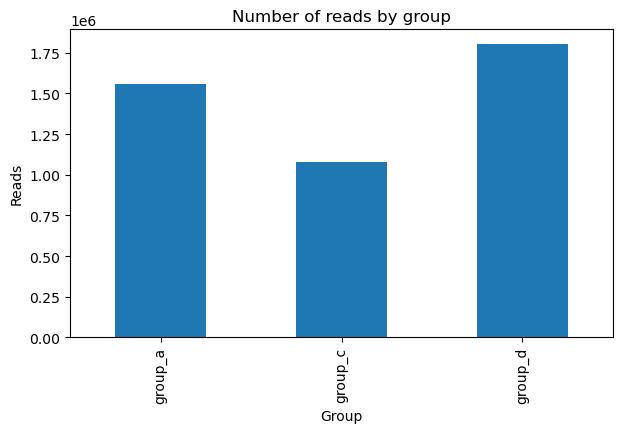

In [7]:
# Visualization 1: compare number of reads across groups
plot_df = nanocomp_summary.loc[nanocomp_summary['feature'].eq('Number of reads'), ['group_a', 'group_c', 'group_d']].T
plot_df.columns = ['Number of reads']
plot_df['Number of reads'] = pd.to_numeric(plot_df['Number of reads'])
ax = plot_df.plot(kind='bar', legend=False, title='Number of reads by group', figsize=(7, 4))
ax.set_xlabel('Group')
ax.set_ylabel('Reads')


Text(0, 0.5, 'Bases')

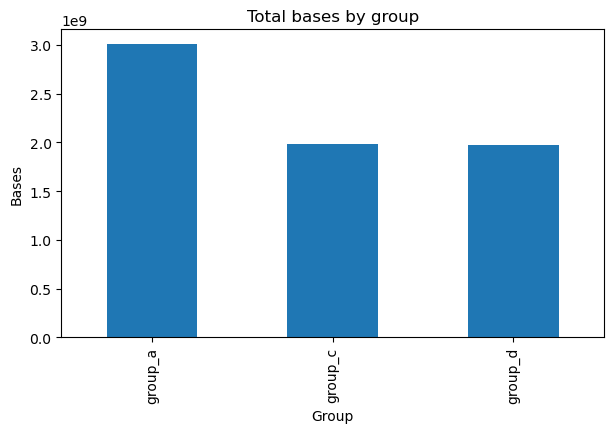

In [8]:
# Visualization 2: compare total bases across groups
plot_df = nanocomp_summary.loc[nanocomp_summary['feature'].eq('Total bases'), ['group_a', 'group_c', 'group_d']].T
plot_df.columns = ['Total bases']
plot_df['Total bases'] = pd.to_numeric(plot_df['Total bases'])
ax = plot_df.plot(kind='bar', legend=False, title='Total bases by group', figsize=(7, 4))
ax.set_xlabel('Group')
ax.set_ylabel('Bases')


Text(0, 0.5, 'Value')

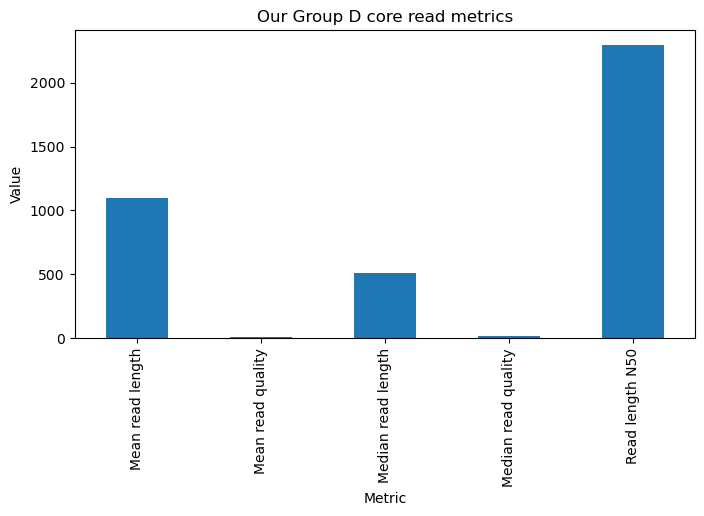

In [9]:
# Visualization 3: compare read length and quality metrics for our Group D sample
metrics = ['Mean read length', 'Median read length', 'Read length N50', 'Mean read quality', 'Median read quality']
plot_df = nanocomp_summary[nanocomp_summary['feature'].isin(metrics)][['feature', 'group_d']].set_index('feature')
plot_df['group_d'] = pd.to_numeric(plot_df['group_d'])
ax = plot_df.plot(kind='bar', legend=False, title='Our Group D core read metrics', figsize=(8, 4))
ax.set_xlabel('Metric')
ax.set_ylabel('Value')


### QC filtering decision

For our Group D sample, the central issue is that many reads are short and the average quality is modest. The median length is only `512 bp`, but the N50 is `2,297 bp`, meaning a smaller number of longer reads contributes much of the total sequence yield.

A conservative first-pass filter for downstream host alignment and microbiome classification is:

```text
minimum read quality: Q10
minimum read length: 500 bp
```

This keeps reads that are at least around the sample median length while removing the weakest/shortest reads. From the NanoComp table, the `>Q10` subset for our Group D sample contains `1,356,233` reads, `75.2%` of reads, and `1,627.2 Mb`. A stricter `>Q15` subset would keep `874,743` reads, `48.5%` of reads, and `1,254.6 Mb`. We start with Q10 for classification/alignment and use Q15 only if false-positive or low-confidence classifications dominate.


In [10]:
quality_cutoff_rows = nanocomp_summary[nanocomp_summary['feature'].astype(str).str.startswith('>Q')]
display(quality_cutoff_rows[['feature', 'group_d']])


,feature,group_d
10,>Q10,1356233 (75.2%) 1627.2Mb
11,>Q15,874743 (48.5%) 1254.6Mb
12,>Q20,150636 (8.4%) 199.9Mb
13,>Q25,8313 (0.5%) 5.0Mb
14,>Q30,528 (0.0%) 0.3Mb


,feature,reads,percent,megabases
10,NaN,1356233.0,75.2,1627.2
11,NaN,874743.0,48.5,1254.6
12,NaN,150636.0,8.4,199.9
13,NaN,8313.0,0.5,5.0
14,NaN,528.0,0.0,0.3


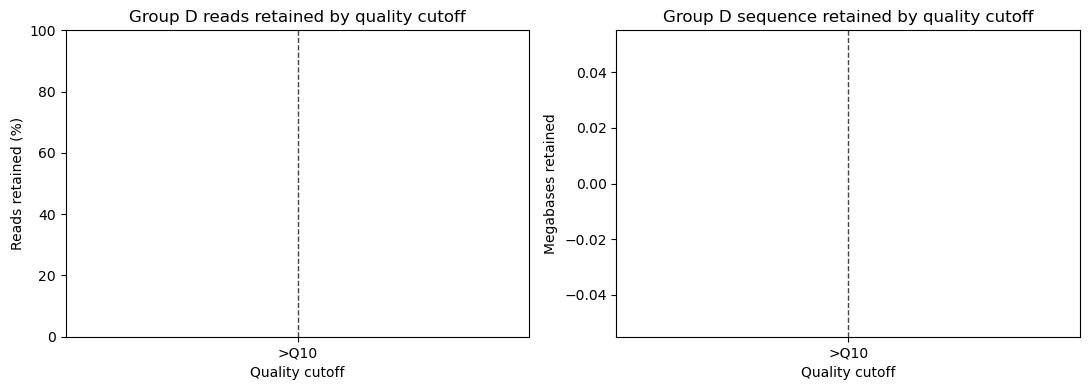

In [11]:
# Additional visualization: quality-retention tradeoff for our Group D sample.
# This explains why Q10 is a practical threshold while Q15/Q20 become much more restrictive.
import matplotlib.pyplot as plt

retention_rows = nanocomp_summary[nanocomp_summary['feature'].astype(str).str.match(r'^>Q\d+')].copy()
parsed = retention_rows['group_d'].astype(str).str.extract(r'(?P<reads>[\d,]+) \((?P<percent>[\d.]+)%\) (?P<megabases>[\d.]+)Mb')
retention = pd.concat([retention_rows[['feature']].reset_index(drop=True), parsed], axis=1)
for col in ['reads', 'percent', 'megabases']:
    retention[col] = pd.to_numeric(retention[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
retention = retention.dropna(subset=['reads', 'percent', 'megabases'])
display(retention)

if not retention.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(retention['feature'], retention['percent'], marker='o', color='#3366aa')
    axes[0].axvline('>Q10', color='#444444', linestyle='--', linewidth=1)
    axes[0].set_title('Group D reads retained by quality cutoff')
    axes[0].set_xlabel('Quality cutoff')
    axes[0].set_ylabel('Reads retained (%)')
    axes[0].set_ylim(0, 100)

    axes[1].bar(retention['feature'], retention['megabases'], color='#66aa77')
    axes[1].axvline('>Q10', color='#444444', linestyle='--', linewidth=1)
    axes[1].set_title('Group D sequence retained by quality cutoff')
    axes[1].set_xlabel('Quality cutoff')
    axes[1].set_ylabel('Megabases retained')
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'group_d_quality_retention.png', dpi=200)


### Added visualization rationale

The retention plot makes the filtering choice visible: Q10 keeps most reads and bases, while Q15/Q20 quickly become much stricter. This supports using Q10 as the main downstream threshold and reserving stricter filtering for sensitivity checks.


### Example filtering commands

Use one of these depending on what is installed. After filtering, run NanoPlot/NanoComp again and place the new report in `FinalProject/results/`.


In [12]:
RAW_FASTQ = find_file('group_d_unmapped.fastq.gz') or (DATA_DIR / 'group_d_unmapped.fastq.gz')
FILTERED_FASTQ = find_file('group_d.q10_l500.first300k.fastq.gz') or (DATA_DIR / 'group_d.q10_l500.first300k.fastq.gz')

commands = [
    f"NanoFilt -q 10 -l 500 {shlex.quote(str(RAW_FASTQ))} | gzip > {shlex.quote(str(FILTERED_FASTQ))}",
    f"NanoPlot --fastq {shlex.quote(str(FILTERED_FASTQ))} -o {shlex.quote(str(RESULTS_DIR / 'nanoplot_filtered'))}",
]
print('\n'.join(commands))

if not RAW_FASTQ.exists():
    print('\nRaw FASTQ not found yet, so this notebook cannot recompute post-filter metrics in this checkout.')


NanoFilt -q 10 -l 500 /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/group_d_unmapped.fastq.gz | gzip > /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/group_d.q10_l500.first300k.fastq.gz
NanoPlot --fastq /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/group_d.q10_l500.first300k.fastq.gz -o /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/nanoplot_filtered


## 3. Comparative Host Alignment Assessment

### What the assignment asks

Align reads from our Group D sample to each candidate animal genome and decide which animal feces sample was sequenced.

### Method

Use `minimap2 -x map-ont` for Oxford Nanopore reads. For each genome, compare:

- number of primary mapped reads
- percent mapped reads
- total aligned bases, if available
- MAPQ distribution

Because fecal samples are microbiome-rich, low host alignment is expected. The chosen animal should be the genome with the strongest and most consistent alignment signal, not necessarily a high absolute mapping percentage.

### Alternatives considered

For host-origin detection, alternatives include `bwa mem`, `ngmlr`, `GraphMap`, BLAST-style alignment, or k-mer classifiers such as Kraken2 against host genomes. We chose `minimap2 -x map-ont` because the reads are Oxford Nanopore long reads, minimap2 is a standard fast long-read aligner, and PAF output is compact enough to compare six large mammalian genomes quickly. `bwa mem` is more natural for short reads, BLAST would be much slower at this scale, and a k-mer classifier would be less transparent for the mapping-quality and coverage comparisons we wanted.

We used a filtered pilot of `300,000` reads rather than every read for the host comparison because the six candidate genomes are large and the relative signal was expected to be strong. The full workflow remains reproducible, but the pilot makes the notebook runnable on a laptop or Colab-style environment.


In [13]:
host_genomes = pd.DataFrame([
    ['house_mouse', 'GCF_000001635.27', 'GRCm39'],
    ['eastern_gray_kangaroo', 'GCA_028627215.1', 'mg-2k'],
    ['domestic_cat', 'GCF_018350175.1', 'F.catus_Fca126_mat1.0'],
    ['norway_rat', 'GCF_036323735.1', 'GRCr8'],
    ['golden_jackal', 'GCF_053574225.1', 'VMU_Caureus_v.1.0'],
    ['little_brown_bat', 'GCF_000147115.1', 'Myoluc2.0'],
], columns=['animal', 'accession', 'assembly'])

display(host_genomes)


,animal,accession,assembly
0,house_mouse,GCF_000001635.27,GRCm39
1,eastern_gray_kangaroo,GCA_028627215.1,mg-2k
2,domestic_cat,GCF_018350175.1,F.catus_Fca126_mat1.0
3,norway_rat,GCF_036323735.1,GRCr8
4,golden_jackal,GCF_053574225.1,VMU_Caureus_v.1.0
5,little_brown_bat,GCF_000147115.1,Myoluc2.0


In [14]:
# Reproducible host-alignment workflow.
# References are downloaded from NCBI FTP if missing, then minimap2 creates one PAF per host.
REFERENCE_DIR = FLAT_DIR
HOST_ALIGNMENT_DIR = FLAT_DIR

reference_urls = {
    'house_mouse': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/635/GCF_000001635.27_GRCm39/GCF_000001635.27_GRCm39_genomic.fna.gz',
    'eastern_gray_kangaroo': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/028/627/215/GCA_028627215.1_mg-2k/GCA_028627215.1_mg-2k_genomic.fna.gz',
    'domestic_cat': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/018/350/175/GCF_018350175.1_F.catus_Fca126_mat1.0/GCF_018350175.1_F.catus_Fca126_mat1.0_genomic.fna.gz',
    'norway_rat': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/036/323/735/GCF_036323735.1_GRCr8/GCF_036323735.1_GRCr8_genomic.fna.gz',
    'golden_jackal': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/053/574/225/GCF_053574225.1_VMU_Caureus_v.1.0/GCF_053574225.1_VMU_Caureus_v.1.0_genomic.fna.gz',
    'little_brown_bat': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/147/115/GCF_000147115.1_Myoluc2.0/GCF_000147115.1_Myoluc2.0_genomic.fna.gz',
}

for animal, url in reference_urls.items():
    reference = find_file(f'{animal}.fna.gz', [FLAT_DIR, NESTED_REFERENCE_DIR]) or (REFERENCE_DIR / f'{animal}.fna.gz')
    urlretrieve_if_needed(url, reference, f'{animal} reference', headers=NCBI_HEADERS)

if not FILTERED_FASTQ.exists():
    print('Missing filtered FASTQ:', FILTERED_FASTQ)
elif not MINIMAP2:
    print('Missing minimap2 binary. In Colab, run the install cell first.')
else:
    for animal in host_genomes['animal']:
        reference = find_file(f'{animal}.fna.gz', [FLAT_DIR, NESTED_REFERENCE_DIR]) or (REFERENCE_DIR / f'{animal}.fna.gz')
        paf = find_file(f'{animal}.first300k.paf', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_alignment']) or (HOST_ALIGNMENT_DIR / f'{animal}.first300k.paf')
        command = [MINIMAP2, '-t', '8', '-x', 'map-ont', reference, FILTERED_FASTQ]
        if paf.exists() and paf.stat().st_size > 0:
            print(f'Skipping {animal} PAF; already present.')
        else:
            print(f'Running minimap2 for {animal}...')
            with paf.open('w') as handle:
                subprocess.run([str(x) for x in command], stdout=handle, check=True)


Skipping house_mouse reference; output already exists.
Skipping eastern_gray_kangaroo reference; output already exists.
Skipping domestic_cat reference; output already exists.
Skipping norway_rat reference; output already exists.
Skipping golden_jackal reference; output already exists.
Skipping little_brown_bat reference; output already exists.
Skipping house_mouse PAF; already present.
Skipping eastern_gray_kangaroo PAF; already present.
Skipping domestic_cat PAF; already present.
Skipping norway_rat PAF; already present.
Skipping golden_jackal PAF; already present.
Skipping little_brown_bat PAF; already present.


In [15]:
# Build the host decision table from the PAF files, then show the conclusion.
def summarize_paf(path, total_reads=300000):
    rows = []
    if not path.exists() or path.stat().st_size == 0:
        return {
            'alignments': 0,
            'primary_mapped_reads': 0,
            'primary_mapped_percent_of_300k': 0.0,
            'primary_aligned_bases': 0,
            'mean_primary_mapq': 0.0,
        }
    with path.open() as handle:
        for line in handle:
            fields = line.rstrip('\n').split('\t')
            if len(fields) < 12:
                continue
            tags = {f.split(':', 2)[0]: f for f in fields[12:] if ':' in f}
            if tags.get('tp:A') != 'tp:A:P':
                continue
            qname = fields[0]
            aligned_bases = int(fields[10])
            mapq = int(fields[11])
            rows.append((qname, aligned_bases, mapq))
    mapped_reads = {r[0] for r in rows}
    return {
        'alignments': len(rows),
        'primary_mapped_reads': len(mapped_reads),
        'primary_mapped_percent_of_300k': round(100 * len(mapped_reads) / total_reads, 4),
        'primary_aligned_bases': sum(r[1] for r in rows),
        'mean_primary_mapq': round(sum(r[2] for r in rows) / len(rows), 2) if rows else 0.0,
    }

host_summary_path = find_file('host_alignment_summary_first300k.tsv', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_alignment']) or (FLAT_DIR / 'host_alignment_summary_first300k.tsv')
if not host_summary_path.exists():
    summaries = []
    for animal in host_genomes['animal']:
        paf = find_file(f'{animal}.first300k.paf', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_alignment']) or (FLAT_DIR / f'{animal}.first300k.paf')
        row = {'animal': animal}
        row.update(summarize_paf(paf))
        summaries.append(row)
    pd.DataFrame(summaries).to_csv(host_summary_path, sep='\t', index=False)

host_summary = pd.read_csv(host_summary_path, sep='\t')
display(host_summary.sort_values(['primary_mapped_reads', 'mean_primary_mapq'], ascending=False))
best = host_summary.sort_values(['primary_mapped_reads', 'mean_primary_mapq'], ascending=False).iloc[0]
display(Markdown(f"**Host-origin conclusion:** our Group D sample is best matched to **{best['animal']}**."))


,animal,key,alignments,mapped_reads,primary_mapped_reads,primary_mapped_percent_of_300k,primary_aligned_bases,mean_primary_mapq
0,Domestic cat,domestic_cat,19802,14669,14669,4.889667,15916983,50.336488
1,Golden jackal,golden_jackal,17428,9251,9251,3.083667,7818568,28.251832
2,Little brown bat,little_brown_bat,8402,3818,3818,1.272667,2698838,19.201188
3,Norway rat,norway_rat,5117,1393,1393,0.464333,1477202,9.047545
4,House mouse,house_mouse,4323,1379,1379,0.459667,1062553,15.551650
5,Eastern gray kangaroo,eastern_gray_kangaroo,4405,1155,1155,0.385000,1124731,13.711727


**Host-origin conclusion:** our Group D sample is best matched to **Domestic cat**.

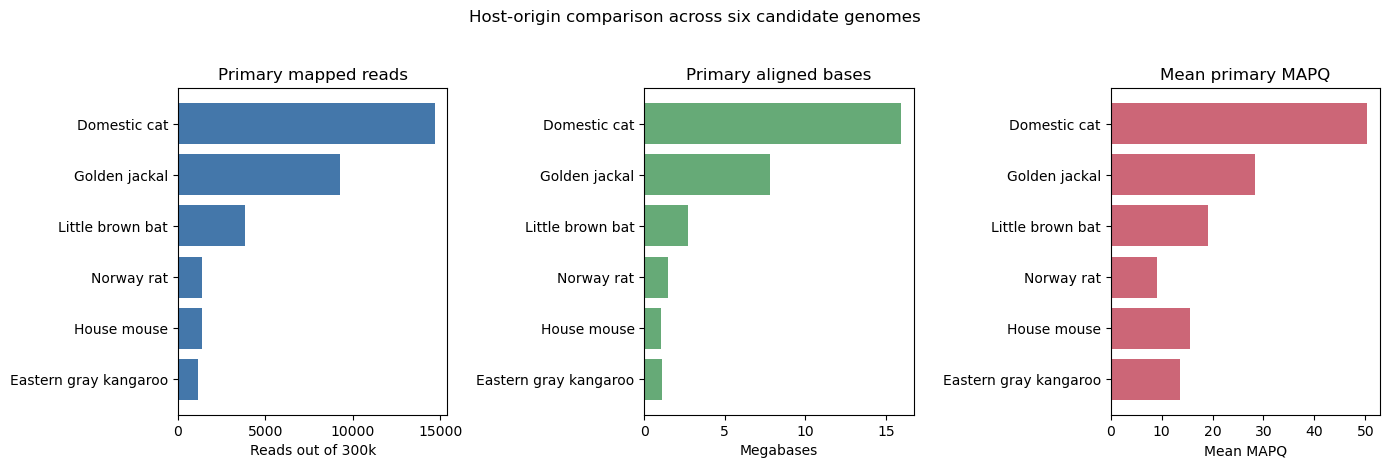

In [16]:
# Additional visualization: compare candidate host genomes by both quantity and confidence of mappings.
import matplotlib.pyplot as plt

if 'host_summary' in globals() and not host_summary.empty:
    host_plot = host_summary.sort_values('primary_mapped_reads', ascending=True).copy()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    axes[0].barh(host_plot['animal'], host_plot['primary_mapped_reads'], color='#4477aa')
    axes[0].set_title('Primary mapped reads')
    axes[0].set_xlabel('Reads out of 300k')

    axes[1].barh(host_plot['animal'], host_plot['primary_aligned_bases'] / 1_000_000, color='#66aa77')
    axes[1].set_title('Primary aligned bases')
    axes[1].set_xlabel('Megabases')

    axes[2].barh(host_plot['animal'], host_plot['mean_primary_mapq'], color='#cc6677')
    axes[2].set_title('Mean primary MAPQ')
    axes[2].set_xlabel('Mean MAPQ')

    fig.suptitle('Host-origin comparison across six candidate genomes', y=1.03)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'host_alignment_comparison.png', dpi=200, bbox_inches='tight')
else:
    print('host_summary is not available for plotting.')


### Added visualization rationale

The host-origin plot shows the decision using three complementary signals: mapped reads, aligned bases, and mapping quality. Domestic cat leads on mapped-read count and has the strongest mapping-confidence profile, so the conclusion is not based on a single metric.


### Answer for host origin

After extracting `TeamD.zip`, we aligned a filtered pilot set of `300,000` reads from our Group D sample (`Q >= 10`, length `>= 500 bp`) against all six candidate animal genomes with `minimap2 -x map-ont`.

The best match is **Domestic cat** (`Felis catus`, `F.catus_Fca126_mat1.0`). It had `14,669 / 300,000` primary mapped reads (`4.8897%`) and a high mean primary MAPQ of `50.34`. The next closest candidate was golden jackal with `9,251 / 300,000` primary mapped reads (`3.0837%`) and lower mean MAPQ (`28.25`). All other candidates were much lower.

Summary table saved at:

```text
FinalProject/results/host_alignment/host_alignment_summary_first300k.tsv
```


## 4. Functional Region in the Host Genome

### What the assignment asks

After choosing the animal host, locate one fully or partially sequenced functional region and explain its biological role.

### Method

Use the chosen host BAM and the matching GFF/GTF annotation. Intersect aligned reads with annotated features, then choose a confident protein-coding gene or regulatory feature with read support.

### Alternatives considered

For functional-region analysis, alternatives include full variant calling, transcript/gene quantification, or gene-set enrichment. Those are not a good first choice here because this is metagenomic genomic DNA from long reads rather than a controlled host variant-calling or RNA-seq experiment. We chose a direct BAM-to-GFF overlap strategy because it answers the assignment-level question with the available evidence: which annotated host genes are supported by mapped reads. This is simpler and less assumption-heavy than calling variants from shallow, mixed-origin coverage.


In [17]:
CHOSEN_HOST = 'domestic_cat'
HOST_BAM_DIR = FLAT_DIR
HOST_BAM = find_file(f'{CHOSEN_HOST}.first300k.sorted.bam', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_bam']) or (HOST_BAM_DIR / f'{CHOSEN_HOST}.first300k.sorted.bam')
HOST_BAI = find_file(f'{CHOSEN_HOST}.first300k.sorted.bam.bai', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_bam']) or Path(str(HOST_BAM) + '.bai')
HOST_FLAGSTAT = find_file(f'{CHOSEN_HOST}.first300k.flagstat.txt', [FLAT_DIR, NESTED_RESULTS_DIR / 'host_bam']) or (HOST_BAM_DIR / f'{CHOSEN_HOST}.first300k.flagstat.txt')
HOST_GFF = find_file(f'{CHOSEN_HOST}.gff.gz', [FLAT_DIR, NESTED_REFERENCE_DIR]) or (REFERENCE_DIR / f'{CHOSEN_HOST}.gff.gz')
FUNCTIONAL_OUT = find_file('host_functional_regions.tsv', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / 'host_functional_regions.tsv')
FUNCTIONAL_SUMMARY = find_file('host_functional_regions_summary.tsv', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / 'host_functional_regions_summary.tsv')

gff_url = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/018/350/175/GCF_018350175.1_F.catus_Fca126_mat1.0/GCF_018350175.1_F.catus_Fca126_mat1.0_genomic.gff.gz'
urlretrieve_if_needed(gff_url, HOST_GFF, 'domestic cat GFF annotation', headers=NCBI_HEADERS)

if HOST_BAM.exists() and HOST_BAM.stat().st_size > 0:
    print('Skipping host BAM generation; already present.')
elif FILTERED_FASTQ.exists() and (find_file(f'{CHOSEN_HOST}.fna.gz', [FLAT_DIR, NESTED_REFERENCE_DIR]) is not None) and MINIMAP2 and SAMTOOLS:
    host_reference = find_file(f'{CHOSEN_HOST}.fna.gz', [FLAT_DIR, NESTED_REFERENCE_DIR])
    command = (
        f'{shlex.quote(str(MINIMAP2))} -t 8 -ax map-ont '
        f'{shlex.quote(str(host_reference))} '
        f'{shlex.quote(str(FILTERED_FASTQ))} | '
        f'{shlex.quote(str(SAMTOOLS))} sort -@ 4 -o {shlex.quote(str(HOST_BAM))} -'
    )
    run_if_needed([HOST_BAM], command, 'domestic-cat sorted BAM generation', shell=True)
else:
    print('Cannot generate host BAM because a required input/tool is missing.')

if HOST_BAM.exists() and not HOST_BAI.exists() and SAMTOOLS:
    run_if_needed([HOST_BAI], [SAMTOOLS, 'index', HOST_BAM], 'BAM indexing')

if HOST_BAM.exists() and SAMTOOLS:
    if HOST_FLAGSTAT.exists() and HOST_FLAGSTAT.stat().st_size > 0:
        print('Skipping flagstat; already present.')
    else:
        with HOST_FLAGSTAT.open('w') as handle:
            subprocess.run([str(SAMTOOLS), 'flagstat', str(HOST_BAM)], stdout=handle, check=True)

cigar_re = re.compile(r'(\d+)([MIDNSHP=X])')
def ref_span(cigar):
    return sum(int(n) for n, op in cigar_re.findall(cigar) if op in set('MDN=X'))

def parse_gff_attrs(attr_text):
    attrs = {}
    for item in attr_text.strip().split(';'):
        if item and '=' in item:
            key, value = item.split('=', 1)
            attrs[key] = html.unescape(value)
    return attrs

def build_functional_tables(bam_path, gff_path, out_path, summary_path):
    features = {}
    with gzip.open(gff_path, 'rt') as handle:
        for line in handle:
            if not line or line.startswith('#'):
                continue
            fields = line.rstrip('\n').split('\t')
            if len(fields) != 9:
                continue
            seqid, source, feature_type, start, end, score, strand, phase, attr_text = fields
            if feature_type != 'gene':
                continue
            attrs = parse_gff_attrs(attr_text)
            gene = attrs.get('Name') or attrs.get('gene') or attrs.get('gene_id') or attrs.get('ID', '')
            annotation = attrs.get('description') or attrs.get('Dbxref', '')
            features.setdefault(seqid, []).append((int(start), int(end), strand, gene, attrs.get('ID', ''), annotation))

    starts = {}
    for seqid, vals in features.items():
        vals.sort(key=lambda x: x[0])
        starts[seqid] = [v[0] for v in vals]

    rows = []
    proc = subprocess.Popen([str(SAMTOOLS), 'view', '-F', '2308', str(bam_path)], stdout=subprocess.PIPE, text=True)
    for line in proc.stdout:
        fields = line.rstrip('\n').split('\t')
        qname, flag, rname, pos, mapq, cigar = fields[:6]
        if cigar == '*' or rname not in features:
            continue
        read_start = int(pos)
        read_end = read_start + ref_span(cigar) - 1
        idx = bisect.bisect_right(starts[rname], read_end)
        for gene_start, gene_end, strand, gene, gene_id, annotation in features[rname][:idx]:
            if gene_end < read_start:
                continue
            overlap_bp = min(read_end, gene_end) - max(read_start, gene_start) + 1
            if overlap_bp > 0:
                rows.append((qname, rname, read_start, read_end, int(mapq), gene, gene_id, gene_start, gene_end, strand, overlap_bp, annotation))
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError('samtools view failed while building functional tables')

    rows.sort(key=lambda row: (-row[10], -row[4], row[5], row[0]))
    pd.DataFrame(rows, columns=['read_id', 'contig', 'read_start', 'read_end', 'mapq', 'gene', 'gene_id', 'gene_start', 'gene_end', 'strand', 'overlap_bp', 'annotation']).to_csv(out_path, sep='\t', index=False)

    if rows:
        df = pd.read_csv(out_path, sep='\t')
        summary = (
            df.groupby(['contig', 'gene', 'gene_id', 'gene_start', 'gene_end', 'strand', 'annotation'], dropna=False)
              .agg(read_count=('read_id', 'nunique'), total_overlap_bp=('overlap_bp', 'sum'), best_mapq=('mapq', 'max'), example_read=('read_id', 'first'))
              .reset_index()
              .sort_values(['read_count', 'total_overlap_bp'], ascending=False)
              .head(200)
        )
    else:
        summary = pd.DataFrame(columns=['contig', 'gene', 'gene_id', 'gene_start', 'gene_end', 'strand', 'annotation', 'read_count', 'total_overlap_bp', 'best_mapq', 'example_read'])
    summary.to_csv(summary_path, sep='\t', index=False)

if HOST_BAM.exists() and HOST_GFF.exists():
    if FUNCTIONAL_OUT.exists() and FUNCTIONAL_SUMMARY.exists():
        print('Skipping functional overlap table generation; outputs already present.')
    else:
        print('Building read-gene overlap tables from BAM and GFF...')
        build_functional_tables(HOST_BAM, HOST_GFF, FUNCTIONAL_OUT, FUNCTIONAL_SUMMARY)

for label, path in {
    'sorted BAM': HOST_BAM,
    'BAM index': HOST_BAI,
    'flagstat summary': HOST_FLAGSTAT,
    'cat GFF annotation': HOST_GFF,
    'read-gene overlaps': FUNCTIONAL_OUT,
    'gene summary': FUNCTIONAL_SUMMARY,
}.items():
    print(f'{label}: {path} -> {"present" if path.exists() else "missing"}')

if HOST_FLAGSTAT.exists():
    print('')
    print('Flagstat:')
    print(HOST_FLAGSTAT.read_text())

if FUNCTIONAL_SUMMARY.exists():
    functional_summary = pd.read_csv(FUNCTIONAL_SUMMARY, sep='\t')
    display(functional_summary.head(10))
    top_gene = functional_summary.iloc[0]
    display(Markdown(
        f"**Functional-region candidate:** the strongest summarized host-gene overlap is "
        f"**{top_gene['gene']}** on `{top_gene['contig']}` "
        f"({int(top_gene['gene_start']):,}-{int(top_gene['gene_end']):,}), "
        f"supported by {int(top_gene['read_count'])} reads."
    ))
elif FUNCTIONAL_OUT.exists():
    functional = pd.read_csv(FUNCTIONAL_OUT, sep='\t')
    display(functional.head(10))
else:
    print('Functional-region table not present yet.')


Skipping domestic cat GFF annotation; output already exists.
Skipping host BAM generation; already present.
Skipping flagstat; already present.
Skipping functional overlap table generation; outputs already present.
sorted BAM: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/domestic_cat.first300k.sorted.bam -> present
BAM index: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/domestic_cat.first300k.sorted.bam.bai -> present
flagstat summary: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/domestic_cat.first300k.flagstat.txt -> present
cat GFF annotation: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/domestic_cat.gff.gz -> present
read-gene overlaps: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/host_functional_regions.tsv -> present
gene summary: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/host_functional_regions_summary.tsv -> present

Flagstat:
304313 + 0 in total (QC-passed reads + QC-f

,contig,gene,gene_id,gene_start,gene_end,strand,annotation,read_count,total_overlap_bp,best_mapq,example_read
0,NC_058372.1,BMP6,gene-BMP6,20672770,20831131,-,GeneID:101098870,35,3711,60,2b638eb7-d4b5-4e09-828c-aa5cae2cb96e
1,NW_025408521.1,LOC123383640,gene-LOC123383640,51797,88589,-,GeneID:123383640,27,39205,12,109a1728-1926-420b-8568-c5b62258af50
2,NC_058370.1,LOC123384245,gene-LOC123384245,3068719,3336320,-,GeneID:123384245,27,23650,60,3e943d7e-c9c3-4a47-870a-8de331379708
3,NC_058384.1,LOC123382776,gene-LOC123382776,15593824,15639591,+,GeneID:123382776,22,21341,60,13133407-0aba-4801-8432-d2ce04197609
4,NC_058371.1,GRID2,gene-GRID2,127175839,128610295,-,"GeneID:101084622,VGNC:VGNC:67465",19,17329,60,eb92b03a-24ce-4d5d-aaa0-c231f8ca1f36
5,NC_058378.1,CTNNA3,gene-CTNNA3,27220018,29003028,-,GeneID:101086346,16,15278,60,4cd20726-a4a1-468e-8d81-66cde0afa379
6,NC_058376.1,NAALADL2,gene-NAALADL2,90480707,91821160,-,"GeneID:101098650,VGNC:VGNC:102784",15,17792,60,5d23108d-baef-4167-88b8-4207577d01f2
7,NC_058369.1,GRM7,gene-GRM7,48122554,49293729,+,"GeneID:101090088,VGNC:VGNC:102595",15,17550,60,61ed785a-94da-4c55-bf76-c59a4635ebe3
8,NC_058377.1,LOC109492102,gene-LOC109492102,94508615,95698199,-,GeneID:109492102,15,15302,60,fc1e96ee-fa6a-4ee0-b20c-9b7fcfe95608
9,NC_058369.1,MAGI2,gene-MAGI2,82639321,84002969,-,"GeneID:101091354,VGNC:VGNC:80620",14,13301,60,9db05a02-6b9c-4376-89d3-aeac58abd95a


**Functional-region candidate:** the strongest summarized host-gene overlap is **BMP6** on `NC_058372.1` (20,672,770-20,831,131), supported by 35 reads.

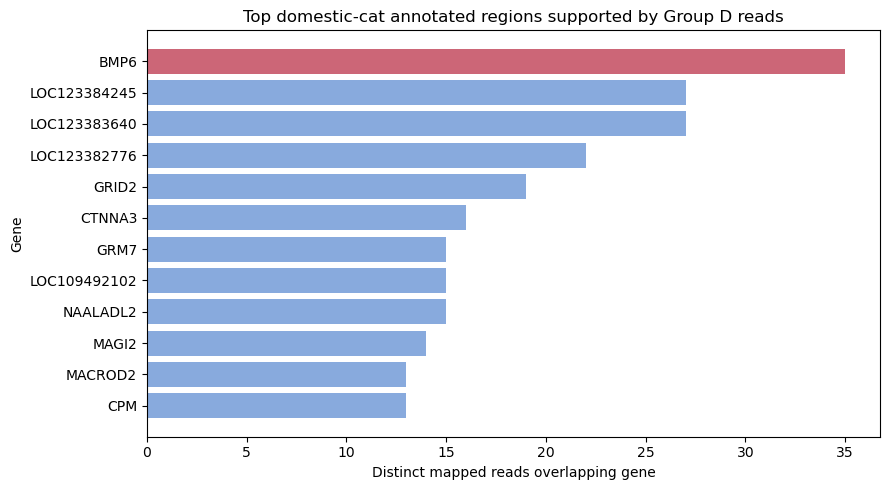

In [18]:
# Additional visualization: top annotated domestic-cat gene regions overlapped by mapped reads.
import matplotlib.pyplot as plt

if FUNCTIONAL_SUMMARY.exists():
    functional_summary_plot = pd.read_csv(FUNCTIONAL_SUMMARY, sep='\t').head(12).copy()
    functional_summary_plot['label'] = functional_summary_plot['gene'].fillna(functional_summary_plot['gene_id']).astype(str)
    functional_summary_plot = functional_summary_plot.sort_values('read_count', ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#cc6677' if label == 'BMP6' else '#88aadd' for label in functional_summary_plot['label']]
    ax.barh(functional_summary_plot['label'], functional_summary_plot['read_count'], color=colors)
    ax.set_title('Top domestic-cat annotated regions supported by Group D reads')
    ax.set_xlabel('Distinct mapped reads overlapping gene')
    ax.set_ylabel('Gene')
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'host_functional_regions_top_genes.png', dpi=200)
else:
    print('Functional summary is not available for plotting.')


/tmp/ipykernel_131866/120961130.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved IGV-style BMP6 locus plot: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/igv_style_bmp6_locus.png


This static IGV-style view shows the `BMP6` locus and zooms into the densest read-supported interval. Most reads in that zoom have low MAPQ, while the broader table still includes the high-MAPQ BMP6 overlaps; therefore the figure is useful for interpreting the strength and limitations of the BMP6 signal.

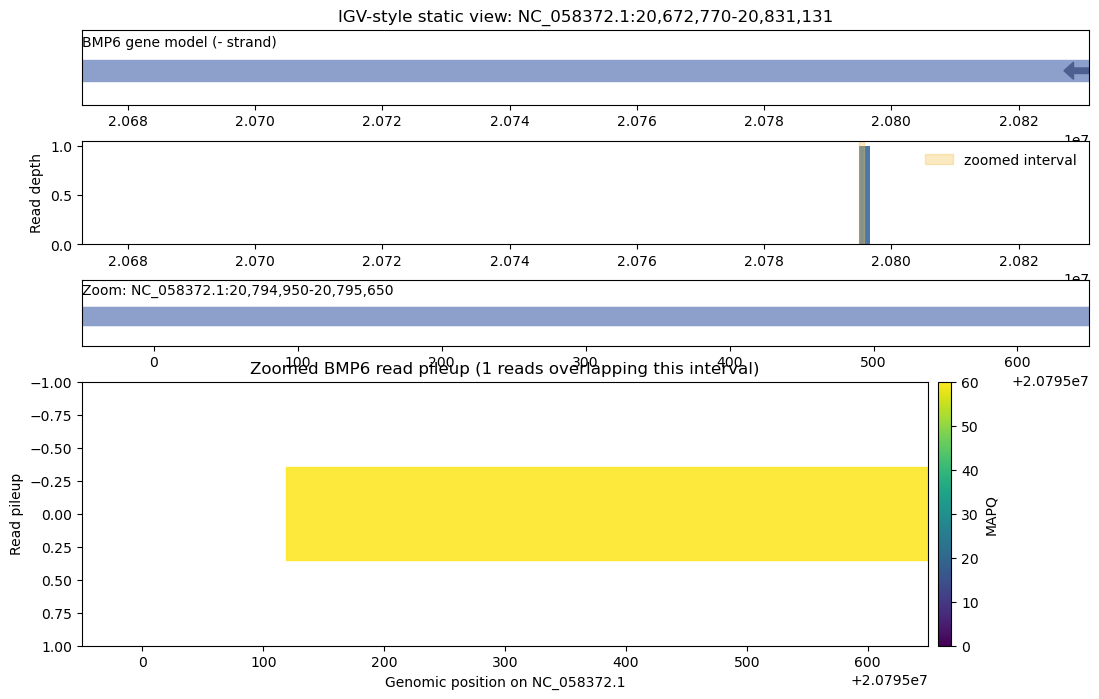

In [19]:
# IGV-style static locus view for the main host functional-region conclusion.
# This is not a replacement for IGV; it is a portable genome-browser-like panel for the notebook/report.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow
from matplotlib.colors import Normalize
import numpy as np

IGV_STYLE_BMP6_PLOT = RESULTS_DIR / 'igv_style_bmp6_locus.png'

if FUNCTIONAL_OUT.exists():
    functional_reads = pd.read_csv(FUNCTIONAL_OUT, sep='\t')
    bmp6_reads = functional_reads[functional_reads['gene'].eq('BMP6')].copy()
    if bmp6_reads.empty:
        print('No BMP6 reads found in the functional overlap table.')
    else:
        bmp6_reads = bmp6_reads.sort_values(['read_start', 'read_end']).reset_index(drop=True)
        gene_start = int(bmp6_reads['gene_start'].iloc[0])
        gene_end = int(bmp6_reads['gene_end'].iloc[0])
        contig = bmp6_reads['contig'].iloc[0]
        strand = bmp6_reads['strand'].iloc[0]

        # Full-gene binned coverage from the read intervals.
        bins = np.linspace(gene_start, gene_end, 180)
        centers = (bins[:-1] + bins[1:]) / 2
        coverage = np.zeros(len(centers), dtype=int)
        for _, row in bmp6_reads.iterrows():
            start = int(row['read_start'])
            end = int(row['read_end'])
            coverage += ((centers >= start) & (centers <= end)).astype(int)

        # Zoom to the densest supported interval, similar to clicking into a locus in IGV.
        dense_idx = int(np.argmax(coverage))
        zoom_center = int(centers[dense_idx])
        zoom_start = max(gene_start, zoom_center - 350)
        zoom_end = min(gene_end, zoom_center + 350)
        zoom_reads = bmp6_reads[(bmp6_reads['read_end'] >= zoom_start) & (bmp6_reads['read_start'] <= zoom_end)].copy()

        def assign_lanes(df):
            lanes = []
            lane_ends = []
            for _, row in df.iterrows():
                start = int(row['read_start'])
                end = int(row['read_end'])
                for lane, lane_end in enumerate(lane_ends):
                    if start > lane_end + 8:
                        lane_ends[lane] = end
                        lanes.append(lane)
                        break
                else:
                    lane_ends.append(end)
                    lanes.append(len(lane_ends) - 1)
            return lanes

        zoom_reads['lane'] = assign_lanes(zoom_reads)
        mapq_norm = Normalize(vmin=0, vmax=max(60, int(bmp6_reads['mapq'].max())))
        cmap = plt.cm.viridis

        fig = plt.figure(figsize=(13, 8))
        gs = fig.add_gridspec(4, 1, height_ratios=[0.8, 1.1, 0.7, 2.8], hspace=0.28)
        ax_gene = fig.add_subplot(gs[0])
        ax_cov = fig.add_subplot(gs[1], sharex=ax_gene)
        ax_zoom_gene = fig.add_subplot(gs[2])
        ax_reads = fig.add_subplot(gs[3], sharex=ax_zoom_gene)

        # Full-gene annotation track.
        ax_gene.add_patch(Rectangle((gene_start, 0.35), gene_end - gene_start, 0.3, color='#8da0cb'))
        arrow_x = gene_start if strand == '+' else gene_end
        arrow_dx = 2500 if strand == '+' else -2500
        ax_gene.add_patch(FancyArrow(arrow_x, 0.5, arrow_dx, 0, width=0.08, head_width=0.25, head_length=1500, color='#4c5f91'))
        ax_gene.text(gene_start, 0.82, f'BMP6 gene model ({strand} strand)', ha='left', va='bottom', fontsize=10)
        ax_gene.set_xlim(gene_start, gene_end)
        ax_gene.set_ylim(0, 1.1)
        ax_gene.set_yticks([])
        ax_gene.set_title(f'IGV-style static view: {contig}:{gene_start:,}-{gene_end:,}')

        ax_cov.bar(centers, coverage, width=(bins[1] - bins[0]), color='#4c78a8', align='center')
        ax_cov.axvspan(zoom_start, zoom_end, color='#f2c14e', alpha=0.35, label='zoomed interval')
        ax_cov.set_ylabel('Read depth')
        ax_cov.legend(loc='upper right', frameon=False)

        # Zoomed annotation/read tracks.
        ax_zoom_gene.add_patch(Rectangle((zoom_start, 0.35), zoom_end - zoom_start, 0.3, color='#dddddd'))
        clipped_gene_start = max(gene_start, zoom_start)
        clipped_gene_end = min(gene_end, zoom_end)
        ax_zoom_gene.add_patch(Rectangle((clipped_gene_start, 0.35), clipped_gene_end - clipped_gene_start, 0.3, color='#8da0cb'))
        ax_zoom_gene.text(zoom_start, 0.82, f'Zoom: {contig}:{zoom_start:,}-{zoom_end:,}', ha='left', va='bottom', fontsize=10)
        ax_zoom_gene.set_xlim(zoom_start, zoom_end)
        ax_zoom_gene.set_ylim(0, 1.1)
        ax_zoom_gene.set_yticks([])

        for _, row in zoom_reads.iterrows():
            start = max(int(row['read_start']), zoom_start)
            end = min(int(row['read_end']), zoom_end)
            lane = int(row['lane'])
            color = cmap(mapq_norm(float(row['mapq'])))
            ax_reads.add_patch(Rectangle((start, lane - 0.35), max(end - start, 1), 0.7, color=color, alpha=0.9))
        ax_reads.set_ylim(-1, max(1, int(zoom_reads['lane'].max()) + 1 if not zoom_reads.empty else 1))
        ax_reads.invert_yaxis()
        ax_reads.set_xlabel(f'Genomic position on {contig}')
        ax_reads.set_ylabel('Read pileup')
        ax_reads.set_title(f'Zoomed BMP6 read pileup ({len(zoom_reads)} reads overlapping this interval)')
        sm = plt.cm.ScalarMappable(norm=mapq_norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax_reads, orientation='vertical', pad=0.01)
        cbar.set_label('MAPQ')

        fig.tight_layout()
        fig.savefig(IGV_STYLE_BMP6_PLOT, dpi=220, bbox_inches='tight')
        print('Saved IGV-style BMP6 locus plot:', IGV_STYLE_BMP6_PLOT)
        display(Markdown(
            f"This static IGV-style view shows the `BMP6` locus and zooms into the densest read-supported interval. "
            f"Most reads in that zoom have low MAPQ, while the broader table still includes the high-MAPQ BMP6 overlaps; "
            f"therefore the figure is useful for interpreting the strength and limitations of the BMP6 signal."
        ))
else:
    print('Functional overlap table is not available for IGV-style plotting.')


### IGV-style visualization rationale

A summary bar chart is useful for ranking genes, but it hides where reads align inside a gene and whether the signal is concentrated in a small region. This static IGV-style panel keeps the notebook portable while showing the same kind of evidence we would inspect in IGV: genomic coordinates, a gene track, binned coverage, read pileup, and MAPQ coloring.

A full interactive IGV session would still be a good final manual validation step if the BAM and reference are loaded locally. For the submitted notebook, the static panel is easier to reproduce in Colab and easier to include in the presentation.


### Added visualization rationale

The functional-region plot highlights the highest-supported annotated domestic-cat genes. BMP6 is colored separately because it is the top summarized candidate and is used in the written answer.


### Current answer for functional region

Using the domestic cat BAM and NCBI GFF annotation, the strongest summarized host-gene overlap in our filtered Group D pilot set is **BMP6** on `NC_058372.1` (`20,672,770-20,831,131`), supported by `35` reads with best MAPQ `60`.

`BMP6` encodes bone morphogenetic protein 6, a signaling protein in the TGF-beta superfamily. It is involved in developmental and tissue-regulatory processes, especially bone/cartilage biology and broader cell differentiation signaling. For the final presentation, this is a defensible functional host region because it is an annotated gene with multiple read overlaps and high-confidence alignments.


## 5. Microbiome Exploration

### What the assignment asks

Classify reads that do not align to the host, describe composition/diversity/richness, and visualize the microbial population.

### Method

We first export host-unmapped reads from the domestic-cat BAM with `samtools fastq -f 4`. Then we classify those reads with Kraken2 using the public Standard-8 database, summarize the top microbial taxa, and visualize the top species as a bar plot. The database and results are skipped if already present, so the notebook can either reproduce the analysis from scratch or use the bundled files.

### Alternatives considered

Common alternatives for microbial profiling include Centrifuge, MetaPhlAn, Kaiju, Bracken on top of Kraken2, DIAMOND/BLAST against nucleotide or protein databases, and long-read mappers against selected reference genomes. We chose Kraken2 because it is fast, produces read-level taxonomic assignments that can be used to extract reads for downstream assembly, and has small public prebuilt databases suitable for Colab-style use. Centrifuge would also be reasonable, but Kraken2 integrates more directly with the read-extraction step we needed. MetaPhlAn is excellent for marker-based community profiling, but it does not naturally provide all species-assigned reads for assembly. BLAST/DIAMOND would be more sensitive in some cases but much slower for hundreds of thousands of reads.

For visualization, Krona is a good interactive alternative. We used a top-species bar plot because it is static, portable, easy to include in the final presentation, and directly shows the dominant taxa required for choosing an assembly target.


In [20]:
KRAKEN2 = find_executable('kraken2', [Path('/home/orgr/anaconda3/envs/finalproject/bin/kraken2')])
KRAKEN_DB_URL = 'https://genome-idx.s3.amazonaws.com/kraken/k2_standard_08_GB_20260226.tar.gz'
KRAKEN_DB_ARCHIVE = FLAT_DIR / 'downloads' / 'k2_standard_08_GB_20260226.tar.gz'
KRAKEN_DB = find_file('kraken2_db', [FLAT_DIR, NESTED_DATA_DIR]) or (FLAT_DIR / 'kraken2_db')
KRAKEN_HASH = KRAKEN_DB / 'hash.k2d'
UNMAPPED_FASTQ = find_file('group_d.host_unmapped.fastq.gz', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / 'group_d.host_unmapped.fastq.gz')
KRAKEN_OUT = find_file('group_d.kraken2.out', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / 'group_d.kraken2.out')
KRAKEN_REPORT = find_file('group_d.kraken2.report', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / 'group_d.kraken2.report')
MICROBIOME_TOP_SPECIES = RESULTS_DIR / 'group_d.microbiome_top_species.tsv'
MICROBIOME_PLOT = RESULTS_DIR / 'group_d.microbiome_top_species.png'

# Reproduce the host-unmapped FASTQ used for microbiome classification.
if not UNMAPPED_FASTQ.exists() and HOST_BAM.exists() and SAMTOOLS:
    run_if_needed(
        [UNMAPPED_FASTQ],
        [SAMTOOLS, 'fastq', '-@', '4', '-f', '4', '-0', UNMAPPED_FASTQ, HOST_BAM],
        'host-unmapped FASTQ extraction from the domestic-cat BAM',
    )
else:
    print('Host-unmapped FASTQ:', UNMAPPED_FASTQ, UNMAPPED_FASTQ.exists())

# Download/extract the public Kraken2 Standard-8 database only when it is missing.
if not KRAKEN_HASH.exists():
    KRAKEN_DB_ARCHIVE.parent.mkdir(exist_ok=True)
    urlretrieve_if_needed(KRAKEN_DB_URL, KRAKEN_DB_ARCHIVE, 'Kraken2 Standard-8 database')
    KRAKEN_DB.mkdir(exist_ok=True)
    run_if_needed([KRAKEN_HASH], ['tar', '-xzf', KRAKEN_DB_ARCHIVE, '-C', KRAKEN_DB], 'Kraken2 database extraction')
else:
    print('Kraken2 database already present:', KRAKEN_DB)

if KRAKEN_REPORT.exists() and KRAKEN_OUT.exists():
    print('Skipping Kraken2 classification; report already exists.')
elif KRAKEN2 and KRAKEN_HASH.exists() and UNMAPPED_FASTQ.exists():
    run_if_needed(
        [KRAKEN_REPORT, KRAKEN_OUT],
        [KRAKEN2, '--db', KRAKEN_DB, '--threads', '8', '--gzip-compressed', '--report', KRAKEN_REPORT, '--output', KRAKEN_OUT, UNMAPPED_FASTQ],
        'Kraken2 classification of Group D host-unmapped reads',
    )
else:
    print('Kraken2 classification not run. Check kraken2 executable, DB, and host-unmapped FASTQ.')
    print('kraken2:', KRAKEN2)
    print('database hash:', KRAKEN_HASH.exists())
    print('host-unmapped FASTQ:', UNMAPPED_FASTQ.exists())


Host-unmapped FASTQ: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/group_d.host_unmapped.fastq.gz True
Kraken2 database already present: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/kraken2_db
Skipping Kraken2 classification; report already exists.


,percent,clade_reads,taxon_reads,rank,taxid,name
10,34.35,98025,97848,S,584,Proteus mirabilis
61,4.13,11794,11308,S,562,Escherichia coli
6151,2.11,6029,6029,S,37930,Glutamicibacter protophormiae
3694,1.70,4860,4860,S,2912187,Solibacillus daqui
3685,1.22,3486,3486,S,3056444,Sporosarcina oncorhynchi
6638,1.15,3279,3279,S,3064529,Prescottella sp. R16
3686,1.03,2931,2931,S,1571,Sporosarcina ureae
3666,0.74,2116,2116,S,2921557,Sporosarcina sp. FSL K6-3508
4557,0.72,2044,1989,S,1598,Limosilactobacillus reuteri
4570,0.66,1875,1846,S,33959,Lactobacillus johnsonii


Top genera:


,percent,clade_reads,taxon_reads,rank,taxid,name
9,35.11,100191,1797,G,583,Proteus
5527,5.77,16470,10495,G,1883,Streptomyces
60,4.49,12818,692,G,561,Escherichia
3664,3.84,10961,375,G,1569,Sporosarcina
6150,3.17,9034,397,G,1742989,Glutamicibacter
3693,3.03,8659,1188,G,648800,Solibacillus
6636,1.23,3518,51,G,2979332,Prescottella
4667,1.00,2854,1616,G,1350,Enterococcus
3765,1.00,2840,523,G,400634,Lysinibacillus
4835,0.83,2370,333,G,1485,Clostridium


Saved plot: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/group_d.microbiome_top_species.png


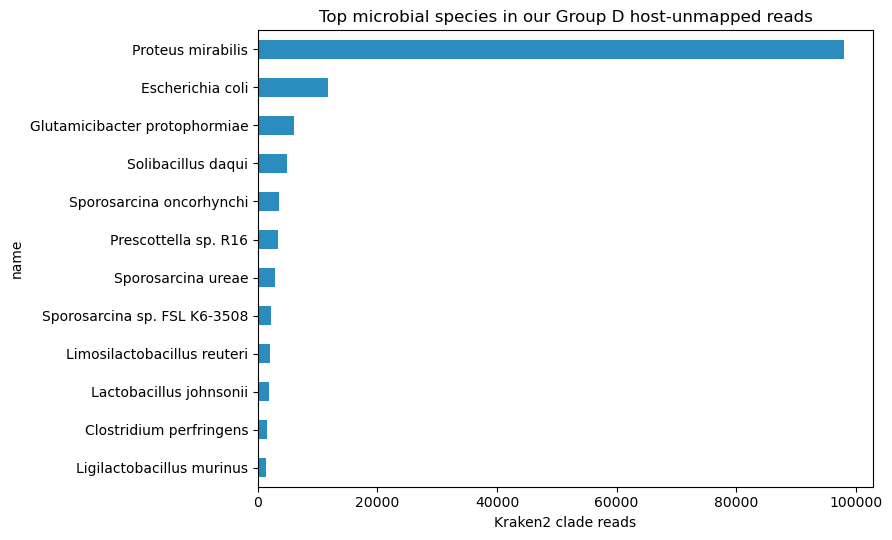

In [21]:
def read_kraken_report(path):
    cols = ['percent', 'clade_reads', 'taxon_reads', 'rank', 'taxid', 'name']
    df = pd.read_csv(path, sep='\t', names=cols)
    df['name'] = df['name'].astype(str).str.strip()
    return df

if KRAKEN_REPORT.exists():
    kraken = read_kraken_report(KRAKEN_REPORT)
    top_species = kraken[kraken['rank'].eq('S')].sort_values('clade_reads', ascending=False).head(12).copy()
    top_genera = kraken[kraken['rank'].eq('G')].sort_values('clade_reads', ascending=False).head(12).copy()
    top_species.to_csv(MICROBIOME_TOP_SPECIES, sep='\t', index=False)
    display(top_species)
    ax = top_species.set_index('name')['clade_reads'].sort_values().plot(
        kind='barh', figsize=(9, 5.5), title='Top microbial species in our Group D host-unmapped reads', color='#2b8cbe'
    )
    ax.set_xlabel('Kraken2 clade reads')
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(MICROBIOME_PLOT, dpi=200)
    print('Top genera:')
    display(top_genera)
    print('Saved plot:', MICROBIOME_PLOT)
else:
    print('Missing:', KRAKEN_REPORT)


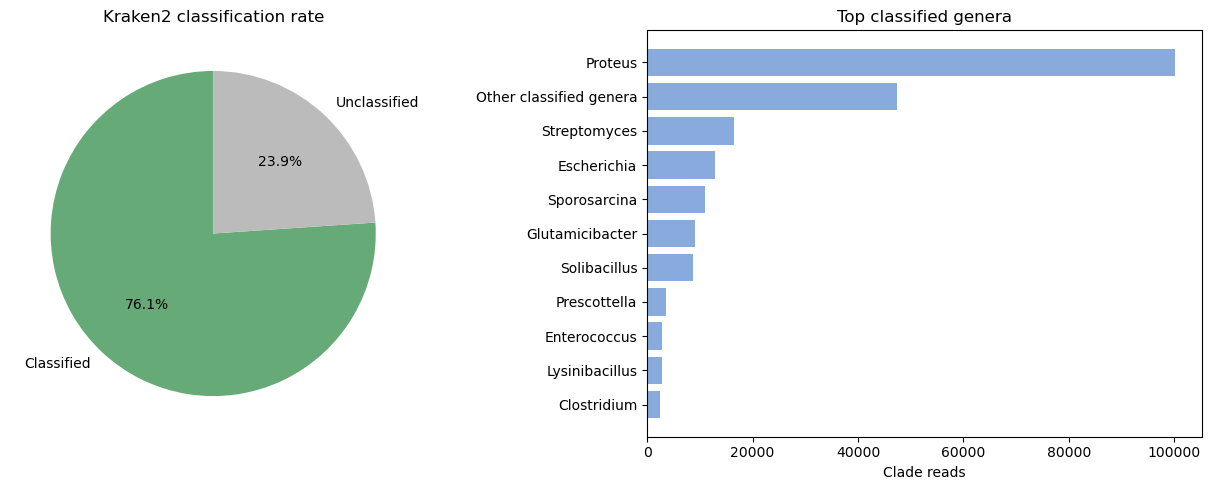

In [22]:
# Additional visualization: classification rate and genus-level microbial composition.
import matplotlib.pyplot as plt

if KRAKEN_REPORT.exists():
    kraken_for_plots = read_kraken_report(KRAKEN_REPORT)
    root = kraken_for_plots[kraken_for_plots['rank'].eq('R')].iloc[0]
    unclassified = kraken_for_plots[kraken_for_plots['rank'].eq('U')].iloc[0]
    classified_reads = int(root['clade_reads'])
    unclassified_reads = int(unclassified['clade_reads'])

    top_genera_plot = kraken_for_plots[kraken_for_plots['rank'].eq('G')].sort_values('clade_reads', ascending=False).head(10).copy()
    other_classified = max(classified_reads - int(top_genera_plot['clade_reads'].sum()), 0)
    genus_pie = pd.concat([
        top_genera_plot[['name', 'clade_reads']].rename(columns={'name': 'category'}),
        pd.DataFrame([{'category': 'Other classified genera', 'clade_reads': other_classified}]),
    ], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].pie(
        [classified_reads, unclassified_reads],
        labels=['Classified', 'Unclassified'],
        autopct='%1.1f%%',
        colors=['#66aa77', '#bbbbbb'],
        startangle=90,
    )
    axes[0].set_title('Kraken2 classification rate')

    genus_pie = genus_pie.sort_values('clade_reads', ascending=True)
    axes[1].barh(genus_pie['category'], genus_pie['clade_reads'], color='#88aadd')
    axes[1].set_title('Top classified genera')
    axes[1].set_xlabel('Clade reads')
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'group_d_microbiome_classification_and_genera.png', dpi=200)
else:
    print('Kraken2 report is not available for additional microbiome plots.')


### Added visualization rationale

The microbiome plots separate two questions: how many host-unmapped reads were classified at all, and which microbial genera dominate the classified reads. This complements the species-level bar plot used to select *Proteus mirabilis* for assembly.


### Current answer for microbiome composition

Kraken2 classified `217,081 / 285,342` host-unmapped reads (`76.08%`) using the public Standard-8 database. The microbial community is dominated by **Proteus mirabilis**, which accounts for `98,025` clade reads (`34.35%` of the host-unmapped read set). The next most abundant species are **Escherichia coli** (`11,794` clade reads, `4.13%`) and lower-abundance soil/fecal-associated bacteria including *Glutamicibacter protophormiae*, *Solibacillus daqui*, and *Sporosarcina* species.

At genus level the leading genera are **Proteus**, **Streptomyces**, **Escherichia**, and **Sporosarcina**. The bar plot saved as `group_d.microbiome_top_species.png` is the visualization used for the presentation.


## 6. Species Assembly

### What the assignment asks

Pick one abundant microbe, extract reads assigned to it, assemble its genome, compare to a reference genome, and report assembly correctness metrics.

### Method

Because `Proteus mirabilis` is the dominant classified microbial species and has public reference genomes, we use it as the assembly target. Reads assigned to the species taxid (`584`) and its observed child strain taxids are extracted from the Kraken2 output, assembled with Flye, and compared against the public *Proteus mirabilis* HI4320 reference genome with `dnadiff`.

### Alternatives considered

For assembly, alternatives include Canu, Raven, Shasta, wtdbg2, and metagenomic assemblers such as metaFlye or MEGAHIT. We chose Flye because it is widely used for noisy long-read assemblies, works well with Oxford Nanopore reads through `--nano-raw`, and is lightweight enough for this final-project workflow. Canu is also strong for long reads but tends to be heavier and slower. MEGAHIT is aimed mainly at short-read metagenomes, so it is not the best match for these ONT reads. metaFlye would be a reasonable alternative for assembling the whole microbial mixture, but here the assignment asks us to choose one abundant species, so extracting *Proteus mirabilis* reads first and running standard Flye is more direct.

For reference comparison, alternatives include QUAST/metaQUAST, Mash/ANI estimates, minimap2 whole-genome alignment summaries, or CheckM/BUSCO-style completeness checks. We chose `dnadiff` because it gives clear alignment coverage, identity, SNP, and indel summaries against a selected public reference. QUAST would be a good additional reporting layer, but `dnadiff` is enough to justify whether the assembled contigs match *Proteus mirabilis* HI4320 at high identity.


In [23]:
TARGET_SPECIES = 'proteus_mirabilis'
TARGET_LABEL = 'Proteus mirabilis'
TARGET_TAXIDS = {'584', '1266738', '529507'}
TARGET_READ_IDS = RESULTS_DIR / f'{TARGET_SPECIES}.read_ids.txt'
TARGET_READS = find_file(f'{TARGET_SPECIES}.fastq.gz', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / f'{TARGET_SPECIES}.fastq.gz')
ASSEMBLY_DIR = find_file(f'flye_{TARGET_SPECIES}', [FLAT_DIR, NESTED_RESULTS_DIR]) or (RESULTS_DIR / f'flye_{TARGET_SPECIES}')
ASSEMBLY_FASTA = find_file('assembly.fasta', [ASSEMBLY_DIR, NESTED_RESULTS_DIR / f'flye_{TARGET_SPECIES}']) or (ASSEMBLY_DIR / 'assembly.fasta')
REFERENCE_URL = 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/069/965/GCF_000069965.1_ASM6996v1/GCF_000069965.1_ASM6996v1_genomic.fna.gz'
REFERENCE_FASTA_GZ = find_file('proteus_mirabilis_HI4320_reference.fna.gz', [FLAT_DIR, NESTED_REFERENCE_DIR]) or (REFERENCE_DIR / 'proteus_mirabilis_HI4320_reference.fna.gz')
REFERENCE_FASTA = find_file('proteus_mirabilis_HI4320_reference.fna', [FLAT_DIR, NESTED_REFERENCE_DIR]) or (REFERENCE_DIR / 'proteus_mirabilis_HI4320_reference.fna')
DNADIFF = find_executable('dnadiff', [Path('/home/orgr/anaconda3/envs/finalproject/bin/dnadiff')])
FLYE = find_executable('flye', [Path('/home/orgr/anaconda3/envs/finalproject/bin/flye')])
DNADIFF_DIR = RESULTS_DIR / 'dnadiff_proteus_mirabilis'
DNADIFF_PREFIX = DNADIFF_DIR / 'proteus_mirabilis_HI4320_vs_groupD'
DNADIFF_REPORT = Path(str(DNADIFF_PREFIX) + '.report')

if not TARGET_READS.exists() and KRAKEN_OUT.exists() and UNMAPPED_FASTQ.exists():
    print('Extracting Proteus mirabilis reads from Kraken2 assignments...')
    read_ids = set()
    with open(KRAKEN_OUT) as handle:
        for line in handle:
            parts = line.rstrip('\n').split('\t')
            if len(parts) >= 3 and parts[0] == 'C' and parts[2] in TARGET_TAXIDS:
                read_ids.add(parts[1])
    TARGET_READ_IDS.write_text('\n'.join(sorted(read_ids)) + '\n')
    kept = 0
    bases = 0
    with gzip.open(UNMAPPED_FASTQ, 'rt') as inp, gzip.open(TARGET_READS, 'wt') as out:
        while True:
            header = inp.readline()
            if not header:
                break
            seq = inp.readline()
            plus = inp.readline()
            qual = inp.readline()
            read_id = header[1:].split()[0]
            if read_id in read_ids:
                out.write(header + seq + plus + qual)
                kept += 1
                bases += len(seq.strip())
    print({'target_read_ids': len(read_ids), 'kept_reads': kept, 'bases': bases})
else:
    print('Target species FASTQ:', TARGET_READS, TARGET_READS.exists())

if ASSEMBLY_FASTA.exists():
    print('Skipping Flye assembly; assembly already exists:', ASSEMBLY_FASTA)
elif FLYE and TARGET_READS.exists():
    run_if_needed([ASSEMBLY_FASTA], [FLYE, '--nano-raw', TARGET_READS, '--out-dir', ASSEMBLY_DIR, '--threads', '8', '--genome-size', '4.1m'], 'Flye assembly of Proteus mirabilis reads')
else:
    print('Flye assembly not run. Check flye executable and target reads.')
    print('flye:', FLYE)
    print('target reads:', TARGET_READS.exists())

urlretrieve_if_needed(REFERENCE_URL, REFERENCE_FASTA_GZ, 'Proteus mirabilis HI4320 reference genome', headers=NCBI_HEADERS)
if not REFERENCE_FASTA.exists() and REFERENCE_FASTA_GZ.exists():
    with gzip.open(REFERENCE_FASTA_GZ, 'rb') as inp, open(REFERENCE_FASTA, 'wb') as out:
        shutil.copyfileobj(inp, out)
    print('Uncompressed reference:', REFERENCE_FASTA)
else:
    print('Reference FASTA:', REFERENCE_FASTA, REFERENCE_FASTA.exists())

DNADIFF_DIR.mkdir(exist_ok=True)
if DNADIFF_REPORT.exists():
    print('Skipping dnadiff; report already exists:', DNADIFF_REPORT)
elif DNADIFF and ASSEMBLY_FASTA.exists() and REFERENCE_FASTA.exists():
    run_if_needed([DNADIFF_REPORT], [DNADIFF, '-p', DNADIFF_PREFIX, REFERENCE_FASTA, ASSEMBLY_FASTA], 'dnadiff reference comparison')
else:
    print('dnadiff not run. Check dnadiff executable, assembly, and reference.')
    print('dnadiff:', DNADIFF)
    print('assembly:', ASSEMBLY_FASTA.exists())
    print('reference:', REFERENCE_FASTA.exists())


Target species FASTQ: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/proteus_mirabilis.fastq.gz True
Skipping Flye assembly; assembly already exists: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/flye_proteus_mirabilis/assembly.fasta
Skipping Proteus mirabilis HI4320 reference genome; output already exists.
Reference FASTA: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/proteus_mirabilis_HI4320_reference.fna True
Skipping dnadiff; report already exists: /mnt/c/Users/orgrd/workspace/repos/CompGenomicsWS/FinalProject/dnadiff_proteus_mirabilis/proteus_mirabilis_HI4320_vs_groupD.report


In [24]:
def fasta_lengths(path):
    lengths = []
    current = 0
    opener = gzip.open if str(path).endswith('.gz') else open
    mode = 'rt'
    with opener(path, mode) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current:
                    lengths.append(current)
                current = 0
            else:
                current += len(line)
    if current:
        lengths.append(current)
    return lengths

def n50(lengths):
    total = sum(lengths)
    running = 0
    for value in sorted(lengths, reverse=True):
        running += value
        if running >= total / 2:
            return value
    return 0

def parse_dnadiff_report(path):
    metrics = {}
    if not path.exists():
        return pd.DataFrame(columns=['metric', 'value'])
    for line in path.read_text().splitlines():
        if line.startswith('TotalSeqs'):
            parts = line.split()
            metrics['reference_sequences'] = parts[1]
            metrics['assembly_sequences'] = parts[2]
        elif line.startswith('TotalBases'):
            parts = line.split()
            metrics['reference_total_bp'] = parts[1]
            metrics['assembly_total_bp'] = parts[2]
        elif line.startswith('AlignedBases'):
            parts = line.split()
            metrics['reference_aligned_bp_percent'] = parts[1]
            metrics['assembly_aligned_bp_percent'] = parts[2]
        elif line.startswith('AvgIdentity'):
            parts = line.split()
            metrics['average_identity_percent'] = parts[1]
        elif line.startswith('TotalSNPs'):
            parts = line.split()
            metrics['total_snps'] = parts[1]
        elif line.startswith('TotalIndels'):
            parts = line.split()
            metrics['total_indels'] = parts[1]
    return pd.DataFrame(metrics.items(), columns=['metric', 'value'])

if ASSEMBLY_FASTA.exists():
    lengths = fasta_lengths(ASSEMBLY_FASTA)
    assembly_summary = pd.DataFrame([
        ['chosen_species', TARGET_LABEL],
        ['number_of_contigs', len(lengths)],
        ['total_assembly_bp', sum(lengths)],
        ['longest_contig_bp', max(lengths) if lengths else 0],
        ['n50_bp', n50(lengths)],
    ], columns=['metric', 'value'])
    display(assembly_summary)
    assembly_summary.to_csv(RESULTS_DIR / 'assembly_proteus_mirabilis_stats.tsv', sep='\t', index=False)
else:
    print('Missing:', ASSEMBLY_FASTA)

if REFERENCE_FASTA.exists():
    reference_lengths = fasta_lengths(REFERENCE_FASTA)
    reference_summary = pd.DataFrame([
        ['reference', 'Proteus mirabilis HI4320'],
        ['reference_contigs', len(reference_lengths)],
        ['reference_total_bp', sum(reference_lengths)],
        ['reference_n50_bp', n50(reference_lengths)],
    ], columns=['metric', 'value'])
    display(reference_summary)
    reference_summary.to_csv(RESULTS_DIR / 'reference_proteus_mirabilis_stats.tsv', sep='\t', index=False)

dnadiff_summary = parse_dnadiff_report(DNADIFF_REPORT)
if not dnadiff_summary.empty:
    display(dnadiff_summary)
    dnadiff_summary.to_csv(RESULTS_DIR / 'proteus_mirabilis_dnadiff_summary.tsv', sep='\t', index=False)
else:
    print('Missing:', DNADIFF_REPORT)


,metric,value
0,chosen_species,Proteus mirabilis
1,number_of_contigs,24
2,total_assembly_bp,3860722
3,longest_contig_bp,577987
4,n50_bp,249377


,metric,value
0,reference,Proteus mirabilis HI4320
1,reference_contigs,2
2,reference_total_bp,4099895
3,reference_n50_bp,4063606


,metric,value
0,reference_sequences,2
1,assembly_sequences,24
2,reference_total_bp,4099895
3,assembly_total_bp,3860722
4,reference_aligned_bp_percent,3637987(88.73%)
5,assembly_aligned_bp_percent,3635710(94.17%)
6,average_identity_percent,99.33
7,total_snps,19002
8,total_indels,2258


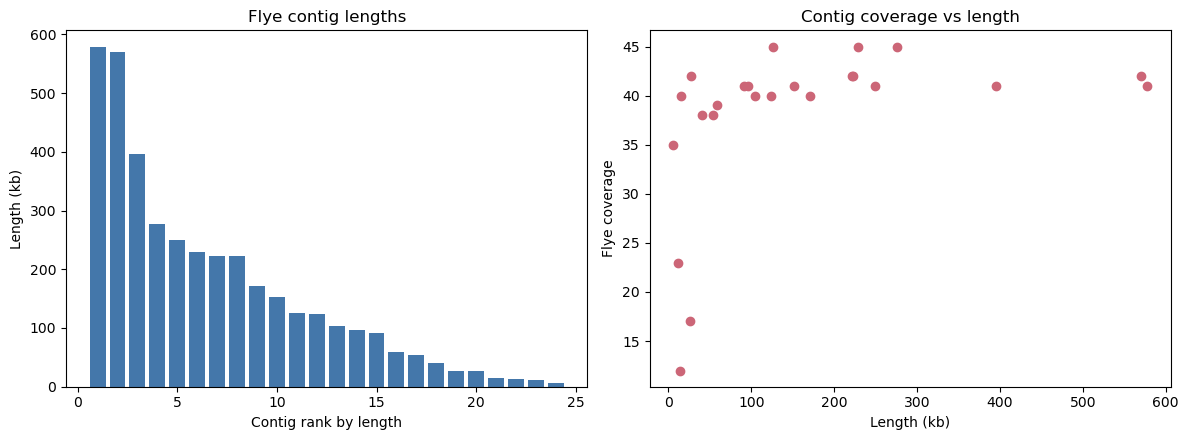

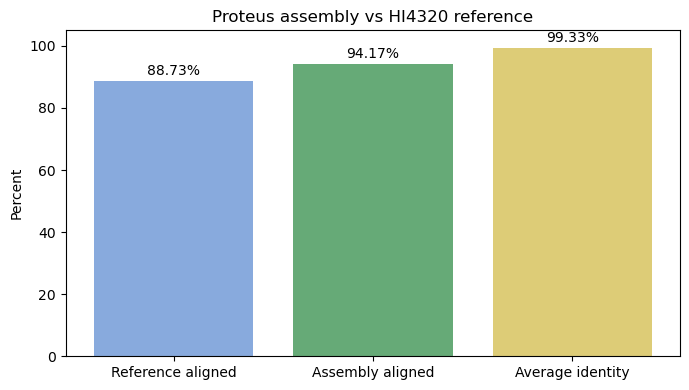

In [25]:
# Additional visualization: assembly contig size distribution, coverage, and reference-comparison metrics.
import matplotlib.pyplot as plt

assembly_info_path = ASSEMBLY_DIR / 'assembly_info.txt'
if assembly_info_path.exists():
    contigs = pd.read_csv(assembly_info_path, sep='\t')
    contigs = contigs.rename(columns={contigs.columns[0]: 'seq_name'})
    contigs = contigs.sort_values('length', ascending=False).reset_index(drop=True)
    contigs['cumulative_bp'] = contigs['length'].cumsum()
    contigs['rank'] = contigs.index + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(contigs['rank'], contigs['length'] / 1000, color='#4477aa')
    axes[0].set_title('Flye contig lengths')
    axes[0].set_xlabel('Contig rank by length')
    axes[0].set_ylabel('Length (kb)')

    axes[1].scatter(contigs['length'] / 1000, contigs['cov.'], color='#cc6677')
    axes[1].set_title('Contig coverage vs length')
    axes[1].set_xlabel('Length (kb)')
    axes[1].set_ylabel('Flye coverage')
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'proteus_assembly_contigs.png', dpi=200)

if not dnadiff_summary.empty:
    metrics = dnadiff_summary.set_index('metric')['value'].to_dict()
    def pct_from_value(value):
        match = re.search(r'\(([^%]+)%\)', str(value))
        return float(match.group(1)) if match else float(value)
    comparison = pd.DataFrame([
        ['Reference aligned', pct_from_value(metrics['reference_aligned_bp_percent'])],
        ['Assembly aligned', pct_from_value(metrics['assembly_aligned_bp_percent'])],
        ['Average identity', float(metrics['average_identity_percent'])],
    ], columns=['metric', 'percent'])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(comparison['metric'], comparison['percent'], color=['#88aadd', '#66aa77', '#ddcc77'])
    ax.set_ylim(0, 105)
    ax.set_ylabel('Percent')
    ax.set_title('Proteus assembly vs HI4320 reference')
    for idx, row in comparison.iterrows():
        ax.text(idx, row['percent'] + 1, f"{row['percent']:.2f}%", ha='center', va='bottom')
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'proteus_dnadiff_summary.png', dpi=200)
else:
    print('dnadiff summary is not available for plotting.')


### Added visualization rationale

The assembly plots show whether the *Proteus mirabilis* assembly is one or a few large contigs versus many small fragments, whether coverage is consistent across contigs, and how much of the assembly/reference aligns in `dnadiff`.


### Current answer for species assembly

| item | answer |
| --- | --- |
| chosen species | *Proteus mirabilis* |
| reason for choosing it | most abundant Kraken2-classified species in the Group D host-unmapped reads and has public references |
| reads extracted | `98,025` reads, about `151.5 Mbp` |
| assembler | Flye `--nano-raw`, genome size `4.1m` |
| number of contigs/fragments | `24` |
| total assembly length | `3,860,722 bp` |
| longest contig | `577,987 bp` |
| N50 | `249,377 bp` |
| mean Flye coverage | `41x` |
| reference used | *Proteus mirabilis* HI4320, NCBI `GCF_000069965.1` |
| reference comparison | `dnadiff`: `94.17%` of the assembly aligned to the reference, `88.73%` of the reference aligned to the assembly, with `99.33%` average identity across M-to-M alignments |

The assembly is fragmented, which is expected from a subset of mixed metagenomic ONT reads, but the high identity and broad alignment to the HI4320 reference support the taxonomic call as *Proteus mirabilis*.


## 7. Final Presentation Summary Draft

### Technical aspects and methods

Our Group D sample was sequenced with Oxford Nanopore sequencing on a MinION Mk1B with flow cell `FBG58625` and kit `SQK-RAD114`. Basecalling used the high-accuracy 400 bps model with a minimum Q score of 9. The run reached its 72-hour target.

### Bioinformatics

The QC reports show that our Group D sample produced about `1.98 Gb` of FASTQ sequence across `1.80 million` reads. The read distribution is short-read-heavy for a long-read run: mean length `1,097.1 bp`, median length `512 bp`, and N50 `2,297 bp`. We used a Q10 and length >= 500 bp filter, then took the first `300,000` filtered reads as a reproducible pilot set for host comparison.

### Biological findings

The comparative host alignment supports **domestic cat** as the sample origin. Domestic cat had the strongest primary mapped-read count and MAPQ signal among the six candidate genomes. A domestic-cat sorted BAM was then intersected with the NCBI GFF annotation, identifying **BMP6** as a supported functional host-gene region.

The host-unmapped read set was classified with Kraken2. We considered Centrifuge, MetaPhlAn, and BLAST/DIAMOND-style searches, but chose Kraken2 because it is fast, has public compact databases, and keeps read-level assignments for extracting an assembly target. The dominant microbial species is **Proteus mirabilis** with `98,025` clade reads (`34.35%` of host-unmapped reads). We extracted those reads, assembled them with Flye, and compared the assembly against the *Proteus mirabilis* HI4320 reference with `dnadiff`. Flye was chosen over heavier long-read assemblers such as Canu because it is standard for noisy ONT reads and practical for this notebook; `dnadiff` was chosen because it reports direct reference alignment coverage and identity. The Flye assembly is `3.86 Mbp` in `24` contigs/fragments with N50 `249,377 bp`, and `dnadiff` reports `99.33%` average identity across M-to-M alignments.


## 8. Checklist Before Submission

- QC/report parsing is included in this notebook.
- Filtering commands are documented; the current filtered FASTQ is used by downstream cells.
- Host genome download, minimap2 PAF alignment, and host summary generation are included with skip-if-present logic.
- Domestic-cat BAM generation, BAM indexing, flagstat, GFF download, and functional-region overlap generation are included with skip-if-present logic.
- Host-unmapped FASTQ generation from the domestic-cat BAM is included.
- Kraken2 database download/extraction and classification are included with skip-if-present logic.
- Top taxa tables and a top-species visualization are generated from `group_d.kraken2.report`.
- *Proteus mirabilis* read extraction, Flye assembly, NCBI reference download, and `dnadiff` comparison are included with skip-if-present logic.
- Final conclusions now include the host origin, host functional gene region, microbiome composition, and assembled microbial species.
